# vgg19에 대해서 공부한다

In [1]:
# !colab
!ls -l /content/drive/MyDrive/robot
import cv2
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

remote_folder = "/content/drive/MyDrive/robot/data"

total 2019
drwx------ 5 root root    4096 Feb 20 01:56  data
drwx------ 2 root root    4096 Jan 15 07:27 'OpenCV Project01'
drwx------ 2 root root    4096 Jan 15 07:27 'OpenCV Project02'
-rw------- 1 root root 2045908 Oct 27 06:20  SmartFactory_과정소개_210314_v2.pdf
drwx------ 2 root root    4096 Nov  3 02:27  src
drwx------ 3 root root    4096 Nov 18 00:17  교육자료
-rw------- 1 root root     174 Feb 13 23:51 '제목 없는 문서.gdoc'


In [2]:
face_images=[]
for i in range(15):
  file_path =f"{remote_folder}/faces/img{i+1:02d}.jpg"
  img=cv2.imread(file_path, cv2.IMREAD_COLOR)
  img=cv2.resize(img, (128,128))
  img=cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
  face_images.append(img)

In [3]:
animal_images=[]
for i in range(15):
  file_path =f"{remote_folder}/animals/img{i+1:02d}.jpg"
  img=cv2.imread(file_path, cv2.IMREAD_COLOR)
  img=cv2.resize(img, (128,128))
  img=cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
  animal_images.append(img)


In [4]:
test_images=[]
for i in range(10):
  file_path =f"{remote_folder}/test_images/img{i+1:02d}.jpg"
  img=cv2.imread(file_path, cv2.IMREAD_COLOR)
  img=cv2.resize(img, (128,128))
  img=cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
  test_images.append(img)

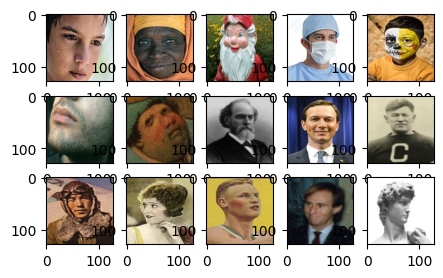

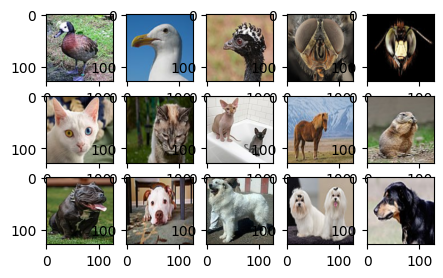

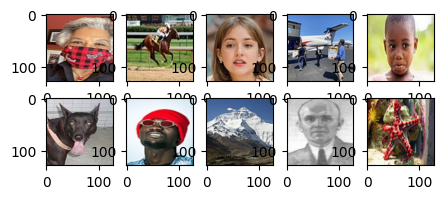

In [5]:
def plot_images(row, col, images):
  (fig, ax) = plt.subplots(row, col, figsize=(col, row))
  for i in range(row):
    for j in range(col):
      ax[i][j].imshow(images[i*col+j])

  plt.show()

plot_images(3,5,face_images)
plot_images(3,5,animal_images)
plot_images(2,5,test_images)


In [6]:
X=face_images+animal_images
y=[[1,0]]*len(face_images) + [[0,1]]*len(animal_images)

In [7]:
X = np.array(X)
y = np.array(y)

In [ ]:
X=X/255.0
test_images=np.array(test_images)
test_images=test_images/255.0

In [9]:
print(X.shape) # 30장 픽셀 128*128 컬러 사진
print(y.shape) # 사람이나 동물이냐 구별 라벨

(30, 128, 128, 3)
(30, 2)


In [ ]:
model=tf.keras.models.Sequential([ # add layers sequentially를 줄일 수 있다.
  # convolution block
  tf.keras.layers.Input(shape=(128,128,3)),
  tf.keras.layers.Conv2D(32, (3,3), activation='relu'),
  tf.keras.layers.MaxPooling2D((2,2), padding='same'),

  # Block 2
  tf.keras.layers.Conv2D(64, (3,3), activation='relu'),
  tf.keras.layers.MaxPooling2D((2,2), padding='same'),

  # fully connected layer
  tf.keras.layers.Flatten(),
  tf.keras.layers.Dense(128, activation='relu'),
  tf.keras.layers.Dense(32, activation='relu'),
  tf.keras.layers.Dense(2, activation='softmax')
])

In [11]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 126, 126, 128)  │         3,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 124, 124, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 62, 62, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 60, 60, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 58, 58, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 29, 29, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 27, 27, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 25, 25, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 13, 13, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 2)              │            66 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,656,290 (59.72 MB)

 Trainable params: 15,656,290 (59.72 MB)

 Non-trainable params: 0 (0.00 B)

In [12]:
model.compile(optimizer=tf.keras.optimizers.Adam(0.001), loss='categorical_crossentropy', metrics=['categorical_accuracy'])

In [ ]:
model.fit(X, y, epochs=20)

Epoch 1/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 34s 34s/step - categorical_accuracy: 0.5000 - loss: 0.6931
Epoch 2/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 41s 41s/step - categorical_accuracy: 0.5000 - loss: 0.6932
Epoch 3/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 41s 41s/step - categorical_accuracy: 0.5000 - loss: 0.6937
Epoch 4/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 30s 30s/step - categorical_accuracy: 0.5000 - loss: 0.6932
Epoch 5/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 31s 31s/step - categorical_accuracy: 0.5000 - loss: 0.6932
Epoch 6/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 45s 45s/step - categorical_accuracy: 0.5000 - loss: 0.6931
Epoch 7/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 37s 37s/step - categorical_accuracy: 0.5000 - loss: 0.6931
Epoch 8/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 41s 41s/step - categorical_accuracy: 0.5000 - loss: 0.6931
Epoch 9/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 31s 31s/step - categorical_accuracy: 0.5000 - loss: 0.6931
Epoch 10/20


In [ ]:
model.save("face_animal_classifier.keras")

In [ ]:
predicts=model.predict(test_images)

In [ ]:
predictions=np.round(predicts)
print(predictions)

**나중에 불러올때**

In [ ]:
cnn_model=tf.keras.models.load_model("face_animal_classifier.keras")
prediction2=cnn_model.predict(test_images)
print(prediction2)